# Chapter 07 — Dense Retrieval, ANN/HNSW, and Quantization

*Where we are:* the second retrieval arm — **semantic** matching — plus the indexing that makes it
scale.

```
chunks →[ embeddings → brute-force → HNSW → quantization ]→ fusion → rerank
```

Embeddings map text to a vector so related passages are close **even without shared words** —
repairing BM25's vocabulary-mismatch weakness. We write the embedder, the exact retriever, the
FAISS HNSW index and the quantized indexes **inline** (they are packaged in `patentrag.dense`). All
inference is **CPU-pinned and deterministic**.

In [1]:
# === Chapter 07 · standard bootstrap (identical pattern in every notebook) ===
# Runs standalone on a fresh Google Colab VM *or* a local checkout.
import os, sys, subprocess

REPO_URL = "https://github.com/rsalehin/patent-rag-masterclass"
NEED_OCR = False
IN_COLAB = "google.colab" in sys.modules


def _clone_repo(url, target):
    """Clone the repo on Colab. For a PRIVATE repo, authenticate with a GitHub token read from
    Colab Secrets (key 'GITHUB_TOKEN') or the GITHUB_TOKEN env var. The token is never printed."""
    token = None
    try:
        from google.colab import userdata  # type: ignore
        token = userdata.get("GITHUB_TOKEN")
    except Exception:
        token = os.environ.get("GITHUB_TOKEN")
    auth_url = url
    if token and url.startswith("https://github.com/"):
        auth_url = url.replace("https://github.com/", f"https://{token}@github.com/")
    r = subprocess.run(["git", "clone", "--depth", "1", auth_url, target],
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)  # avoid leaking the token
    if r.returncode != 0:
        raise RuntimeError(
            "git clone failed. This is a PRIVATE repo, so Colab needs a GitHub token:\n"
            "  1) Create a token (scope: repo) at https://github.com/settings/tokens\n"
            "  2) In Colab, open the key icon (Secrets) in the left sidebar, add a secret named\n"
            "     GITHUB_TOKEN, paste the token, and enable 'Notebook access'.\n"
            "  3) Re-run this cell.\n"
            "  (Alternatively, make the GitHub repo public — then no token is needed.)")


if IN_COLAB:
    target = "/content/patent-rag-masterclass"
    if not os.path.isdir(target):
        if not REPO_URL:
            raise RuntimeError("Set REPO_URL to this repo's GitHub URL (see README.md).")
        _clone_repo(REPO_URL, target)
    os.chdir(target)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if NEED_OCR:
        subprocess.run(["apt-get", "install", "-y", "-q", "tesseract-ocr"], check=False)

# Ensure the repo root (containing patentrag/) is importable.
for _cand in [os.getcwd()] + [os.path.dirname(os.getcwd())]:
    if os.path.isdir(os.path.join(_cand, "patentrag")):
        if _cand not in sys.path:
            sys.path.insert(0, _cand)
        break

from patentrag import bootstrap as bs
bs.setup_environment(REPO_URL, need_ocr=NEED_OCR)
bs.set_seeds()
_env = bs.environment_report()
print("Chapter 07 bootstrap OK")
print("  Python", _env["python"], "| Colab:", _env["in_colab"], "| CPU cores:", _env["cpu_count"])
print("  torch", _env["torch"], "| CUDA:", _env["cuda_available"], "| tesseract:", _env["tesseract"])

Chapter 07 bootstrap OK
  Python 3.12.10 | Colab: False | CPU cores: 24
  torch 2.12.0.dev20260304+cu130 | CUDA: True | tesseract: True


## 23. Embeddings & similarity

An embedding model maps text → a vector $\mathbf{v}\in\mathbb{R}^d$. With **L2-normalized** vectors,
**cosine similarity** equals the dot product:

$$\cos(\mathbf{a},\mathbf{b})=\frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\lVert\mathbf{b}\rVert}\;\xrightarrow{\;\lVert\mathbf{a}\rVert=\lVert\mathbf{b}\rVert=1\;}\;\mathbf{a}\cdot\mathbf{b}$$

Below is the inline embedder (packaged as `patentrag.dense.get_embedder`/`embed`).

In [2]:
import numpy as np                                       # arrays + linear algebra
from sentence_transformers import SentenceTransformer    # the embedding-model library

# Load MiniLM once, pinned to CPU for determinism/portability (a GPU would be used if we let it).
# all-MiniLM-L6-v2: 384-dim, tiny, the reproducible baseline (bge-small/e5-small are stronger upgrades).
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cpu")

def embed(texts):
    """Encode a list of texts to a float32 matrix with L2-normalized rows (so dot == cosine)."""
    return model.encode(list(texts),                     # accept any iterable of strings
                        normalize_embeddings=True,        # unit-length rows -> dot product IS cosine
                        convert_to_numpy=True,            # return a numpy array (not torch tensor)
                        show_progress_bar=False).astype(np.float32)  # compact dtype

probe = [
    "approximate nearest neighbor search over dense vectors",
    "finding the closest vectors quickly in a large index",   # paraphrase (few shared words)
    "a recipe for tomato basil soup",                         # unrelated
]
V = embed(probe)                                             # shape (3, 384)
print("embedding dim:", V.shape[1])
print(f"cos(ANN, paraphrase) = {float(V[0] @ V[1]):.3f}   (semantically close)")   # high
print(f"cos(ANN, soup)       = {float(V[0] @ V[2]):.3f}   (unrelated)")            # low

C:\Users\rsalehin\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7265.25it/s]

embedding dim: 384
cos(ANN, paraphrase) = 0.757   (semantically close)
cos(ANN, soup)       = 0.050   (unrelated)


## 24. Brute-force (exact) dense retrieval

Exact cosine search is one matrix multiply: $\text{scores} = M\mathbf{q}$ over normalized
embeddings, then take the top-k. We build it inline (packaged as `patentrag.dense.DenseRetriever`).
We reuse the cached corpus embeddings (`embeddings` artifact) — built by the *same* `embed()` — to
avoid re-encoding all 1,044 chunks.

In [3]:
import pandas as pd
emb = bs.ensure("embeddings")                            # cached: {'chunk_ids', 'matrix' (N x 384), 'dim'}
chunks = bs.ensure("chunks"); by_id = {c.chunk_id: c for c in chunks}  # chunk lookup for display
ids, matrix = emb["chunk_ids"], emb["matrix"]            # parallel arrays: id[i] <-> matrix[i]

class DenseRetriever:                                     # inline == patentrag.dense.DenseRetriever
    def __init__(self, chunk_ids, matrix):
        self.chunk_ids = chunk_ids                        # id per row
        self.matrix = matrix.astype(np.float32)           # (N, d) normalized embeddings
    def search(self, query, k=10):
        q = embed([query])[0] if isinstance(query, str) else query  # embed the query if it's text
        sims = self.matrix @ q                            # (N,) cosine similarity to every chunk (one matmul)
        order = np.argsort(-sims)[:k]                     # indices of the k highest scores (descending)
        return [(self.chunk_ids[i], float(sims[i])) for i in order]  # (chunk_id, score) pairs
    def exact_topk(self, q, k):
        return list(np.argsort(-(self.matrix @ q))[:k])   # exact top-k row indices (ground truth for ANN)

dense = DenseRetriever(ids, matrix)                       # build over the corpus
q = "how do you keep millions of feature vectors and find close ones fast?"
pd.DataFrame([{"pub": by_id[c].publication_number, "section": by_id[c].section[:16],
               "cos": round(s, 3), "text": by_id[c].text[:48]} for c, s in dense.search(q, 6)])

,pub,section,cos,text
0,US11714853B2,BACKGROUND,0.663,Many distributed and fog computing applications
1,US11714853B2,EMBODIMENTS OF T,0.649,"Accordingly, this disclosure presents various em"
2,US11714853B2,EMBODIMENTS OF T,0.636,"In the illustrated embodiment, a nearest neighbo"
3,US11714853B2,EMBODIMENTS OF T,0.630,"As an example, using traditional data storage so"
4,US11714853B2,EMBODIMENTS OF T,0.628,"For example, there are various “in-memory” libra"
5,US11714853B2,EMBODIMENTS OF T,0.627,The described feature vector management system p


### Lexical vs semantic — a query where dense wins

For a paraphrase with little lexical overlap, BM25 struggles while dense retrieval finds the right
patent by meaning.

In [4]:
bm25 = bs.ensure("bm25_index")                           # the sparse retriever from Ch 06
paraphrase = "let shoppers get product suggestions instantly from learned taste vectors"
target = "US11113744B2"                                  # personalized recommendations via deep embeddings
def first_rank_of_doc(results):                          # position of the first hit belonging to `target`
    for r, (cid, _) in enumerate(results, 1):
        if by_id[cid].document_id == target:
            return r
    return None
print("query:", paraphrase)
print("  BM25  first rank of target doc:", first_rank_of_doc(bm25.search(paraphrase, 50)))
print("  Dense first rank of target doc:", first_rank_of_doc(dense.search(paraphrase, 50)))

query: let shoppers get product suggestions instantly from learned taste vectors
  BM25  first rank of target doc: 19
  Dense first rank of target doc: 1


## 25–26. Exact NN vs Approximate NN — HNSW

Brute force is $O(N)$ per query — fine for thousands, ruinous for millions. **HNSW** builds a
layered proximity graph and navigates it greedily in ~$O(\log N)$. Knobs: **`M`** (links/node),
**`efConstruction`** (build-time breadth), **`efSearch`** (query-time breadth = the recall↔latency
dial). We build a real FAISS HNSW index inline (packaged as `patentrag.dense.HNSWIndex`).

In [5]:
import faiss                                              # Facebook AI Similarity Search (C++/py)

d = emb["dim"]                                            # vector dimension (384)
hnsw = faiss.IndexHNSWFlat(d, 32)                         # HNSW index, M=32 links per node
hnsw.hnsw.efConstruction = 200                            # build-time candidate breadth (graph quality)
hnsw.add(matrix)                                          # insert all corpus vectors (builds the graph)
# NOTE: IndexHNSWFlat uses L2 distance; on L2-NORMALIZED vectors, nearest-by-L2 == nearest-by-cosine.

def recall_at_k(approx_ids, exact_ids):                  # fraction of the exact top-k also found by ANN
    if not exact_ids:
        return 1.0
    return len(set(approx_ids) & set(exact_ids)) / len(exact_ids)

qv = matrix[7]                                            # use an existing corpus vector as the query
exact = set(dense.exact_topk(qv, 10))                    # brute-force ground-truth top-10
for ef in [8, 16, 32, 64]:                               # sweep the query-time breadth
    hnsw.hnsw.efSearch = ef                               # set the dial
    _dist, idx = hnsw.search(qv.reshape(1, -1), 10)       # search returns (distances, indices); take indices
    print(f"  efSearch={ef:3d}  recall@10 vs exact = {recall_at_k(list(idx[0]), list(exact)):.2f}")
print(f"\n(Only {len(ids)} vectors -> HNSW is trivially exact here; the real regime needs many more, next.)")

  efSearch=  8  recall@10 vs exact = 1.00
  efSearch= 16  recall@10 vs exact = 1.00
  efSearch= 32  recall@10 vs exact = 1.00
  efSearch= 64  recall@10 vs exact = 1.00

(Only 1044 vectors -> HNSW is trivially exact here; the real regime needs many more, next.)


### Recall vs latency — the real ANN regime (synthetic vectors)

Our corpus is too small to *exhibit* the trade-off, so we build a **synthetic** index of 50,000
random 384-d vectors (clearly labelled — not patent data) to show how `efSearch` trades recall
against latency versus an exact baseline.

In [6]:
import time
bs.set_seeds()                                           # fixed seeds -> reproducible synthetic data
rng = np.random.default_rng(0)
N = 50000                                                # number of synthetic vectors
X = rng.standard_normal((N, d)).astype("float32"); faiss.normalize_L2(X)   # random, then unit-normalized
Q = rng.standard_normal((300, d)).astype("float32"); faiss.normalize_L2(Q) # 300 query vectors

flat = faiss.IndexFlatL2(d); flat.add(X)                 # exact index = ground truth
_g, gt = flat.search(Q, 10)                              # exact top-10 for each query

hn = faiss.IndexHNSWFlat(d, 32); hn.hnsw.efConstruction = 200; hn.add(X)   # the ANN index
rows = []
for ef in [8, 16, 32, 64, 128, 256]:                     # sweep efSearch
    hn.hnsw.efSearch = ef
    t0 = time.perf_counter(); _dd, I = hn.search(Q, 10); ms = (time.perf_counter() - t0) / len(Q) * 1000
    rec = np.mean([len(set(I[i]) & set(gt[i])) / 10 for i in range(len(Q))])  # mean recall@10 over queries
    rows.append({"efSearch": ef, "recall@10": round(float(rec), 3), "ms/query": round(ms, 3)})
recdf = pd.DataFrame(rows); recdf

,efSearch,recall@10,ms/query
0,8,0.047,0.018
1,16,0.097,0.030
2,32,0.176,0.053
3,64,0.303,0.095
4,128,0.481,0.172
5,256,0.694,0.291


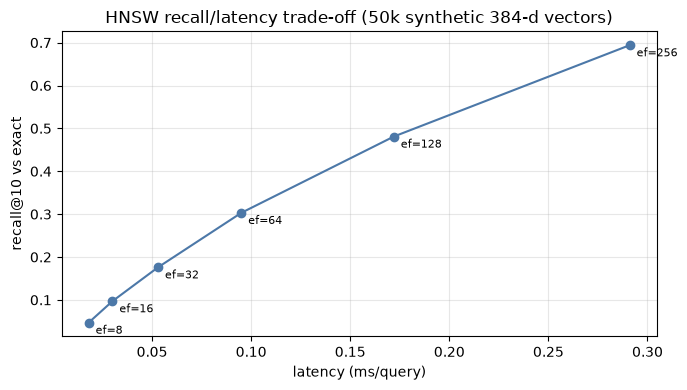

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(recdf["ms/query"], recdf["recall@10"], "o-", color="#4C78A8")   # the trade-off curve
for _, r in recdf.iterrows():                            # annotate each point with its efSearch
    ax.annotate(f"ef={int(r['efSearch'])}", (r["ms/query"], r["recall@10"]),
                fontsize=8, textcoords="offset points", xytext=(5, -8))
ax.set_xlabel("latency (ms/query)"); ax.set_ylabel("recall@10 vs exact")
ax.set_title("HNSW recall/latency trade-off (50k synthetic 384-d vectors)")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 27. Why quantization exists — the memory wall

$$\text{memory} = N \times d \times \text{bytes/scalar}$$

At patent scale (100M+ vectors) float32 is enormous. Compress the *scalars* (float16, int8) or the
*vectors* (product quantization).

In [8]:
def memory_report(n_vectors, dim):                       # GB to store n vectors under several encodings
    gb = lambda bytes_: bytes_ / 1e9
    return {
        "float32_GB": gb(n_vectors * dim * 4),           # 4 bytes/scalar
        "float16_GB": gb(n_vectors * dim * 2),           # 2 bytes/scalar
        "int8_GB":    gb(n_vectors * dim * 1),           # 1 byte/scalar
        "pq_m48_GB":  gb(n_vectors * 48),                # product quant: 48 bytes/vector total
    }
pd.DataFrame([{"encoding": k.replace("_GB", ""), "GB for 100M×384": round(v, 1)}
             for k, v in memory_report(100_000_000, d).items()])

,encoding,GB for 100M×384
0,float32,153.6
1,float16,76.8
2,int8,38.4
3,pq_m48,4.8


## 28. Product Quantization / compressed search

**PQ** splits each vector into $m$ sub-vectors, learns a codebook per subspace, and stores each
vector as $m$ byte-codes — a big memory cut at some accuracy cost. **Scalar int8** quantizes each
dimension to a byte (4× smaller, near-exact). Both are built inline (packaged as
`patentrag.dense.PQIndex` / `ScalarInt8Index`).

In [9]:
# Product Quantization: m=48 sub-quantizers, 8 bits each -> 48 bytes/vector (vs 384*4=1536).
pq = faiss.IndexPQ(d, 48, 8)
pq.train(matrix)                                          # learn the codebooks from the data
pq.add(matrix)                                            # encode + store all vectors as codes
_dp, pq_idx = pq.search(qv.reshape(1, -1), 10)           # approximate search via the codes

# Scalar int8: quantize each dimension to one byte (a QT_8bit flat index).
sc = faiss.IndexScalarQuantizer(d, faiss.ScalarQuantizer.QT_8bit)
sc.train(matrix); sc.add(matrix)
_ds, sc_idx = sc.search(qv.reshape(1, -1), 10)

pq_r = recall_at_k(list(pq_idx[0]), list(exact))         # PQ recall vs exact (lossy)
sc_r = recall_at_k(list(sc_idx[0]), list(exact))         # int8 recall vs exact (near-exact)
pd.DataFrame([
    {"index": "float32 flat (exact)", "bytes/vector": d * 4, "recall@10": 1.00},
    {"index": "scalar int8",          "bytes/vector": d,     "recall@10": round(sc_r, 2)},
    {"index": "product quant (m=48)", "bytes/vector": 48,    "recall@10": round(pq_r, 2)},
])

,index,bytes/vector,recall@10
0,float32 flat (exact),1536,1.0
1,scalar int8,384,1.0
2,product quant (m=48),48,0.9


> The inline `DenseRetriever`, HNSW build, `memory_report`, PQ and int8 code above are exactly what
> `patentrag.dense` packages (`DenseRetriever`, `HNSWIndex`, `PQIndex`, `ScalarInt8Index`,
> `memory_report`), so later chapters import instead of re-deriving.

**Production implications.** Below ~1M vectors, exact or int8-flat is simplest and accurate. Beyond
that, HNSW (tune `M`/`efSearch` for your recall target) and PQ/IVF-PQ trade memory for a little
recall — always **measure recall against an exact baseline** before shipping a compression.

## Chapter invariants

In [10]:
assert V.shape == (3, 384)                                          # embedder produces 384-d vectors
assert float(V[0] @ V[1]) > float(V[0] @ V[2])                      # paraphrase closer than unrelated
assert recdf["recall@10"].iloc[-1] >= recdf["recall@10"].iloc[0]    # recall rises with efSearch
mr = memory_report(100_000_000, d)
assert mr["float32_GB"] > mr["int8_GB"] > mr["pq_m48_GB"]           # memory ordering
assert sc_r >= pq_r                                                 # int8 near-exact >= PQ
from patentrag.dense import DenseRetriever as PkgDR                 # packaged version exists + agrees
assert PkgDR(ids, matrix).search(q, 3)[0][0] == dense.search(q, 3)[0][0]
print("All Chapter 07 invariants hold. embeddings + ann_index artifacts ready.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7962.79it/s]

All Chapter 07 invariants hold. embeddings + ann_index artifacts ready.


In [11]:
# === Chapter 07 validation footer ===
import time, platform, sys, importlib.metadata as _md
_pkgs = ['sentence-transformers', 'torch', 'faiss-cpu', 'numpy']
print("Chapter 07 — environment")
print("  Python :", sys.version.split()[0], "on", platform.system(), platform.release())
for _p in _pkgs:
    try: print(f"  {_p:24}: {_md.version(_p)}")
    except Exception: print(f"  {_p:24}: (not installed)")
print()
print("CHAPTER 07 VALIDATION: PASS")

Chapter 07 — environment
  Python : 3.12.10 on Windows 11
  sentence-transformers   : 6.0.0
  torch                   : 2.12.0.dev20260304+cu130
  faiss-cpu               : 1.15.0
  numpy                   : 2.4.2

CHAPTER 07 VALIDATION: PASS
